# Simulate tSZ temperature maps at different frequencies

Convert the FLAMINGO / Yang et al. (2026) **lensed Compton-$y$** map into
thermodynamic CMB temperature maps $\Delta T_\mathrm{tSZ}(\nu)$ at chosen
observing frequencies.

Following Yang et al. (2026, eq. 3), the **non-relativistic** thermal SZ spectrum is

$$
\frac{\Delta T_\mathrm{tSZ}}{T_\mathrm{CMB}}
=
y\,f(x),
\qquad
f(x)=x\coth\!\left(\frac{x}{2}\right)-4,
\qquad
x=\frac{h\nu}{k_B T_\mathrm{CMB}}.
$$

Output maps are in $\mu\mathrm{K}_\mathrm{CMB}$:

$$
\Delta T_\mathrm{tSZ}(\nu)
=
\bigl(T_\mathrm{CMB}/10^{-6}\,\mathrm{K}\bigr)\,y\,f(x)
\quad[\mu\mathrm{K}].
$$

| Input | Path |
|-------|------|
| Lensed $y$ | `.../lensed_tSZ_rot_same_rot.hdf5` |

> **Kernel**: `cosmo_env`.  
> This notebook uses the **non-relativistic** kernel only (no $T_e$-dependent
> SZpack correction). Relativistic tSZ needs a $y$-weighted electron-temperature map.
>
> Frequencies are treated as **monochromatic** channel centres (no bandpass
> convolution).

In [1]:
from pathlib import Path

import h5py
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as const
from astropy import units as u

# ---------------------------------------------------------------------------
# Global controls
# ---------------------------------------------------------------------------
DATA_DIR = Path(
    "/home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo"
    "/L2p8_m9/integrated_maps/yang26/lightcone0_shells"
)
OUT_DIR = DATA_DIR / "simulated"
YSZ_FILE = DATA_DIR / "lensed_tSZ_rot_same_rot.hdf5"

NSIDE_FULL = 4096
NSIDE_DOWNGRADE = 256
USE_DOWNGRADE = False   # True -> Nside=256 preview; False -> native 4096
NSIDE = NSIDE_DOWNGRADE if USE_DOWNGRADE else NSIDE_FULL

# CMB temperature (Yang et al. use 2.73 K for kSZ; use COBE/FIRAS value here)
T_CMB = 2.7255  # K

# Observing frequencies [GHz] — Planck HFI + common CMB bands
FREQUENCIES_GHZ = [90.0, 150.0, 353.0]

assert YSZ_FILE.is_file(), f"Missing tSZ map: {YSZ_FILE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"USE_DOWNGRADE={USE_DOWNGRADE} -> Nside={NSIDE}")
print(f"Frequencies [GHz]: {FREQUENCIES_GHZ}")

USE_DOWNGRADE=False -> Nside=4096
Frequencies [GHz]: [100.0, 143.0, 217.0, 353.0, 545.0, 857.0]


In [2]:
# Publication-style Matplotlib + LaTeX
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

FREQ_COLORS = {
    90.0: "#56B4E9",
    150.0: "#0072B2",
    353.0: "#E69F00",
}

## 1. Non-relativistic tSZ spectral function

$$
f(x)=x\coth(x/2)-4,
\qquad
x=h\nu/(k_B T_\mathrm{CMB}).
$$

$f(x)$ is negative below the null ($\nu_\mathrm{null}\approx 217.6\,\mathrm{GHz}$),
zero at the null, and positive at higher frequencies.

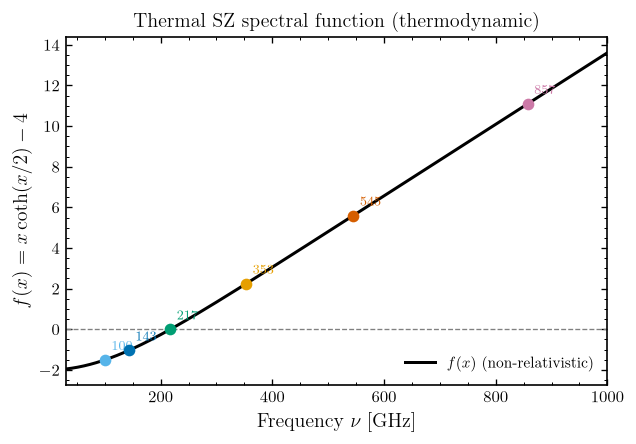

   ν [GHz]         x        f(x)    T_CMB f [μK]
--------------------------------------------------
     100.0    1.7609    -1.50810     -4110327.70
     143.0    2.5180    -1.04036     -2835511.38
     217.0    3.8211    -0.00778       -21191.07
     353.0    6.2159     2.24074      6107144.00
     545.0    9.5967     5.59803     15257429.62
     857.0   15.0906    11.09064     30227536.12


In [3]:
def tsz_x(nu_ghz: float | np.ndarray, t_cmb: float = T_CMB) -> np.ndarray:
    """Dimensionless frequency x = h ν / (k_B T_CMB)."""
    nu = np.asarray(nu_ghz, dtype=np.float64) * u.GHz
    x = (const.h * nu / (const.k_B * t_cmb * u.K)).to_value(u.dimensionless_unscaled)
    return x


def tsz_f(nu_ghz: float | np.ndarray, t_cmb: float = T_CMB) -> np.ndarray:
    """Non-relativistic tSZ spectral function f(x) in thermodynamic temperature."""
    x = tsz_x(nu_ghz, t_cmb=t_cmb)
    # stable coth: coth(z) = cosh(z)/sinh(z)
    return x / np.tanh(0.5 * x) - 4.0


def y_to_delta_T_uK(y: np.ndarray, nu_ghz: float, t_cmb: float = T_CMB) -> np.ndarray:
    """Convert Compton-y map to ΔT in μK_CMB at frequency nu_ghz."""
    return (t_cmb * 1.0e6) * y * tsz_f(nu_ghz, t_cmb=t_cmb)


# Spectrum plot
nu_grid = np.linspace(30.0, 1000.0, 800)
f_grid = tsz_f(nu_grid)

fig, ax = plt.subplots(figsize=(5.4, 3.8))
ax.axhline(0.0, color="0.5", lw=0.8, ls="--")
ax.plot(nu_grid, f_grid, color="k", lw=1.8, label=r"$f(x)$ (non-relativistic)")

for nu in FREQUENCIES_GHZ:
    ax.plot(nu, tsz_f(nu), "o", color=FREQ_COLORS.get(nu, "C0"), ms=6, zorder=3)
    ax.annotate(
        rf"${nu:.0f}$",
        (nu, tsz_f(nu)),
        textcoords="offset points",
        xytext=(4, 6),
        fontsize=8,
        color=FREQ_COLORS.get(nu, "k"),
    )

ax.set_xlabel(r"Frequency $\nu\;[\mathrm{GHz}]$")
ax.set_ylabel(r"$f(x)=x\coth(x/2)-4$")
ax.set_title(r"Thermal SZ spectral function (thermodynamic)")
ax.set_xlim(30, 1000)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT_DIR / "tsz_spectral_function.pdf")
fig.savefig(OUT_DIR / "tsz_spectral_function.png")
plt.show()

print(f"{'ν [GHz]':>10s}  {'x':>8s}  {'f(x)':>10s}  {'T_CMB f [μK]':>14s}")
print("-" * 50)
for nu in FREQUENCIES_GHZ:
    x = tsz_x(nu)
    f = tsz_f(nu)
    print(f"{nu:10.1f}  {x:8.4f}  {f:10.5f}  {T_CMB * 1e6 * f:14.2f}")

## 2. Load the lensed Compton-$y$ map

Yang et al. release the integrated, lensed $y$ map (star-forming / recently AGN-heated
gas excluded). We optionally downgrade for fast visualisation.

In [4]:
print(f"Loading {YSZ_FILE.name}...")
with h5py.File(YSZ_FILE, "r") as f:
    y = f["data"][:].astype(np.float64)

if y.size != 12 * NSIDE_FULL**2:
    raise ValueError(f"Unexpected map size {y.size}")

if USE_DOWNGRADE:
    y = hp.ud_grade(y, NSIDE)

print(
    f"y-map: Nside={hp.npix2nside(y.size)}, "
    f"mean={y.mean():.4e}, std={y.std():.4e}, "
    f"min={y.min():.4e}, max={y.max():.4e}"
)

Loading lensed_tSZ_rot_same_rot.hdf5...
y-map: Nside=4096, mean=1.6109e-06, std=2.0697e-06, min=-2.3690e-05, max=4.7941e-04


## 3. Build $\Delta T_\mathrm{tSZ}(\nu)$ maps

For each frequency,

$$
\Delta T_\mathrm{tSZ}(\nu) = T_\mathrm{CMB}^{(\mu\mathrm{K})}\,y\,f(x(\nu)).
$$

In [5]:
tsz_maps = {}
for nu in FREQUENCIES_GHZ:
    dt = y_to_delta_T_uK(y, nu)
    tsz_maps[nu] = dt
    print(
        f"{nu:6.1f} GHz: mean={dt.mean():+.4e} μK, "
        f"std={dt.std():.4e} μK, "
        f"min={dt.min():+.4e}, max={dt.max():+.4e}"
    )

 100.0 GHz: mean=-6.6214e+00 μK, std=8.5070e+00 μK, min=-1.9705e+03, max=+9.7372e+01
 143.0 GHz: mean=-4.5677e+00 μK, std=5.8685e+00 μK, min=-1.3594e+03, max=+6.7172e+01
 217.0 GHz: mean=-3.4137e-02 μK, std=4.3858e-02 μK, min=-1.0159e+01, max=+5.0201e-01
 353.0 GHz: mean=+9.8380e+00 μK, std=1.2640e+01 μK, min=-1.4468e+02, max=+2.9279e+03
 545.0 GHz: mean=+2.4578e+01 μK, std=3.1578e+01 μK, min=-3.6144e+02, max=+7.3146e+03
 857.0 GHz: mean=+4.8694e+01 μK, std=6.2561e+01 μK, min=-7.1608e+02, max=+1.4492e+04


## 4. Visualize frequency maps

Each panel uses a symmetric colour scale set by the 99th percentile of $|\Delta T|$ at
that frequency (so the sign flip across the tSZ null is visible).

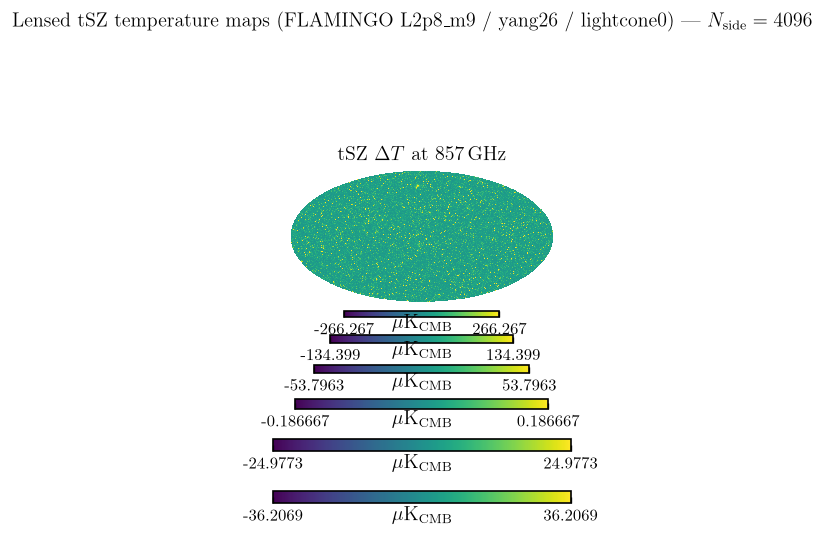

In [6]:
plot_freqs = [90.0, 150.0, 353.0]

for i, nu in enumerate(plot_freqs, start=1):
    m = tsz_maps[nu]
    vmax = np.percentile(np.abs(m), 99)
    # Avoid a zero colour bar exactly at the null
    if vmax < 1e-6:
        vmax = 1e-3
    hp.mollview(
        m,
        title=rf"tSZ $\Delta T$ at ${nu:.0f}\,\mathrm{{GHz}}$",
        unit=r"$\mu\mathrm{K}_\mathrm{CMB}$",
        min=-vmax,
        max=vmax,
        sub=(2, 3, i),
        hold=True,
    )

plt.suptitle(
    r"Lensed tSZ temperature maps (FLAMINGO L2p8\_m9 / yang26 / lightcone0)"
    + (rf" — $N_{{\mathrm{{side}}}}={NSIDE}$"),
    y=1.02,
    fontsize=12,
)
fig = plt.gcf()
fig.savefig(OUT_DIR / f"tsz_deltaT_mollview_nside{NSIDE}.pdf")
fig.savefig(OUT_DIR / f"tsz_deltaT_mollview_nside{NSIDE}.png")
plt.show()

## 5. Frequency scaling check

Because $\Delta T(\nu)\propto f(\nu)\,y$, the ratio of maps at two frequencies must equal
$f(\nu_1)/f(\nu_2)$ (constant on the sky, away from the null).

f(143)/f(353) theory = -0.464294
median map ratio on bright pixels = -0.464294
relative difference = 0.000e+00 %


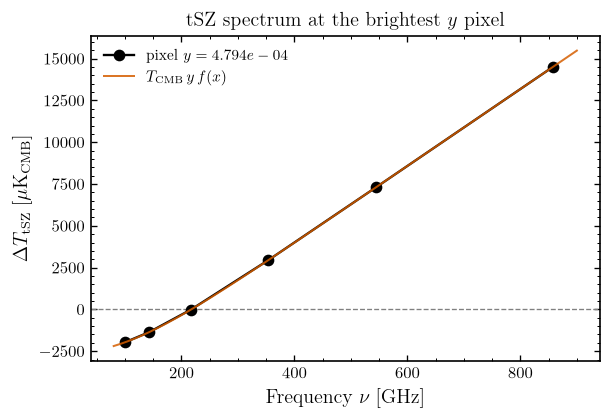

In [7]:
nu1, nu2 = 143.0, 353.0
f1, f2 = tsz_f(nu1), tsz_f(nu2)
ratio_theory = f1 / f2
ratio_map = tsz_maps[nu1] / tsz_maps[nu2]

# Restrict to pixels where |ΔT_353| is not tiny
mask = np.abs(tsz_maps[nu2]) > np.percentile(np.abs(tsz_maps[nu2]), 50)
ratio_med = np.median(ratio_map[mask])

print(f"f({nu1:g})/f({nu2:g}) theory = {ratio_theory:.6f}")
print(f"median map ratio on bright pixels = {ratio_med:.6f}")
print(f"relative difference = {(ratio_med / ratio_theory - 1.0) * 100:.3e} %")

# SED for a high-y pixel
ipix = int(np.argmax(y))
sed = np.array([tsz_maps[nu][ipix] for nu in FREQUENCIES_GHZ])

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.axhline(0.0, color="0.5", lw=0.8, ls="--")
ax.plot(
    FREQUENCIES_GHZ, sed, "o-", color="k", lw=1.4, ms=6,
    label=rf"pixel $y={y[ipix]:.3e}$",
)
nu_fine = np.linspace(80, 900, 400)
ax.plot(
    nu_fine, y_to_delta_T_uK(y[ipix], nu_fine),
    color="#D55E00", lw=1.2, alpha=0.85, label=r"$T_\mathrm{CMB}\,y\,f(x)$",
)
ax.set_xlabel(r"Frequency $\nu\;[\mathrm{GHz}]$")
ax.set_ylabel(r"$\Delta T_\mathrm{tSZ}\;[\mu\mathrm{K}_\mathrm{CMB}]$")
ax.set_title(r"tSZ spectrum at the brightest $y$ pixel")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUT_DIR / f"tsz_SED_brightest_pixel_nside{NSIDE}.pdf")
fig.savefig(OUT_DIR / f"tsz_SED_brightest_pixel_nside{NSIDE}.png")
plt.show()

## 6. Save frequency maps

HEALPix FITS maps in $\mu\mathrm{K}_\mathrm{CMB}$ (RING ordering).

In [8]:
tag = f"nside{NSIDE}"
saved = []
for nu in FREQUENCIES_GHZ:
    path = OUT_DIR / f"tSZ_deltaT_{nu:.0f}GHz_{tag}.fits"
    hp.write_map(
        path,
        tsz_maps[nu],
        overwrite=True,
        dtype=np.float64,
        column_names=["TEMPERATURE"],
        extra_header=[
            ("UNIT", "uK_CMB"),
            ("FREQ", float(nu), "GHz monochromatic"),
            ("TCMB", float(T_CMB), "K"),
            ("YSZ", str(YSZ_FILE.name)),
            ("KERNEL", "non-relativistic f(x)=x*coth(x/2)-4"),
        ],
    )
    saved.append(path)

# Also save the (possibly downgraded) y map used
path_y = OUT_DIR / f"compton_y_used_{tag}.fits"
hp.write_map(path_y, y, overwrite=True, dtype=np.float64, column_names=["COMPTON_Y"])
saved.append(path_y)

print("Wrote:")
for p in saved:
    print(f"  {p}")

Wrote:
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/tSZ_deltaT_100GHz_nside4096.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/tSZ_deltaT_143GHz_nside4096.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/tSZ_deltaT_217GHz_nside4096.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/tSZ_deltaT_353GHz_nside4096.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/tSZ_deltaT_545GHz_nside4096.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/tSZ_deltaT_857GHz_nside4096.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/

## Notes

1. **Non-relativistic only** — Yang et al. also discuss relativistic corrections via
   SZpack using a $y$-weighted $T_e$ map. That product is not in the downloaded
   `lightcone0_shells` set, so it is omitted here.
2. **Monochromatic frequencies** — for a Planck-like analysis, replace $f(\nu_0)$ by a
   bandpass average $\int f(\nu)\,\tau(\nu)\,d\nu/\int \tau(\nu)\,d\nu$.
3. **Null frequency** — near $217\,\mathrm{GHz}$, $|\Delta T_\mathrm{tSZ}|$ is very small;
   residual signal there is dominated by relativistic corrections and bandpass effects
   in real data.
4. **Next step** — coadd with lensed primary CMB + kSZ + CIB($\nu$) at the same
   frequencies to build multi-frequency sky maps.

### References

1. Yang et al. (2026), MNRAS 548 — eq. (3), tSZ map construction
2. Sunyaev & Zeldovich (1972, 1980) — thermal SZ effect
3. Carlstrom, Holder & Reese (2002) — SZ review